## Overview figures

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

Running Scanpy 1.10.3, on 2025-03-10 17:41.


In [2]:
## path variables
adata_dir = '/mnt/smb/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispe

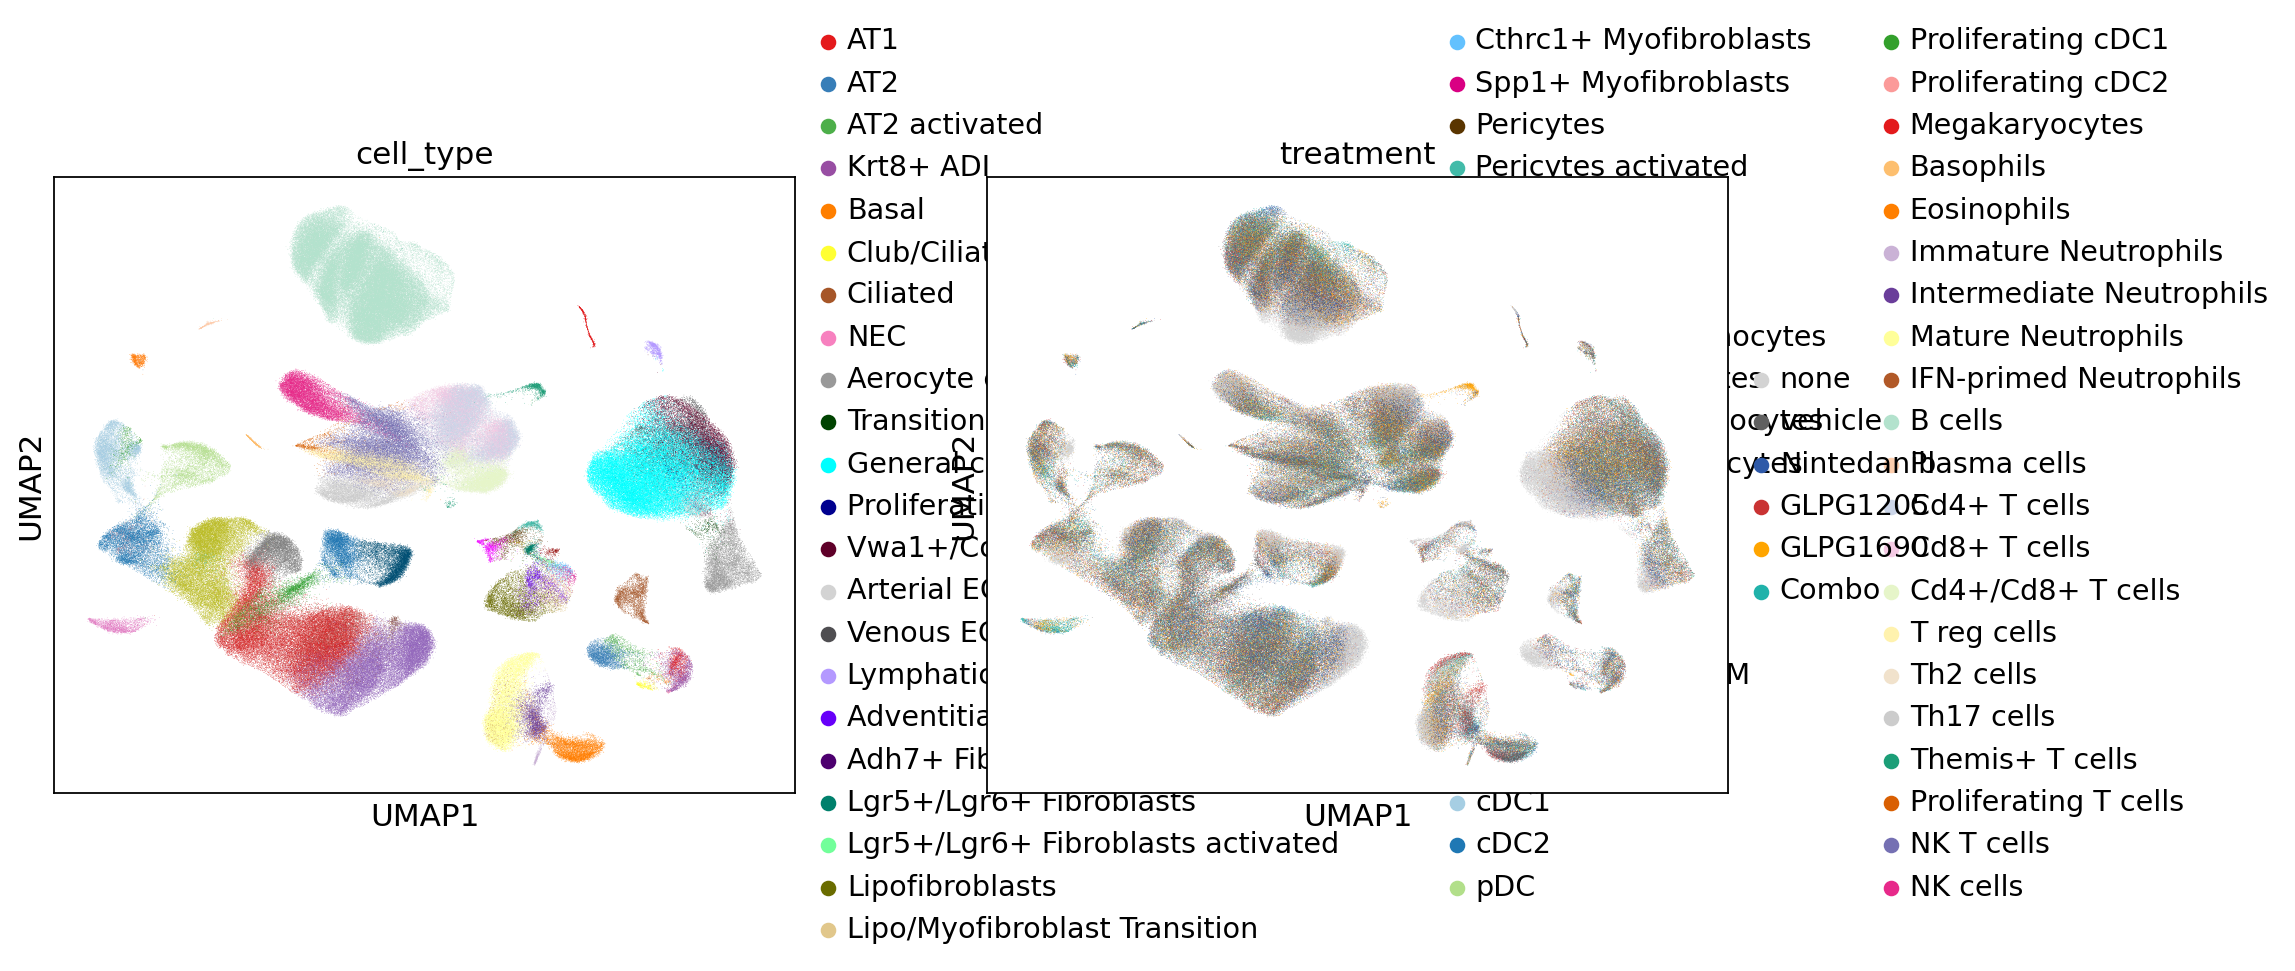

In [6]:
sc.pl.umap(adata, color = ['cell_type','treatment'])

In [7]:
## target gene dict
lpa_receptors = {
    'LPA-R1' : ['Lpar1'],
    'LPA-R2' : ['Lpar2'],
    'LPA-R3' : ['Lpar3'],
    'LPA-R4' : ['Lpar4'],
    'LPA-R5' : ['Lpar5'],
    'LPA-R6' : ['Lpar6'],
    'Alternative LPA-R' : ['Gpr87']
          }

### Harmonize metadata labels

In [8]:
adata.obs.treatment.cat.categories

Index(['none', 'vehicle', 'Nintedanib', 'GLPG1205', 'GLPG1690', 'Combo'], dtype='object')

In [9]:
## harmonize cell types with human data (limited by cell type resolution of hPCLS)
ct_rename = {
    ## epithelial cells
    'AT2 activated' : 'AT2', 
    'Club/Ciliated' : 'Secretory',
    'NEC' : 'Other',
    ## endothelial cells
    'Aerocyte capillary EC' : 'capillary EC', 
    'Transitional capillary EC' : 'capillary EC',
    'General capillary EC' : 'capillary EC',
    'Proliferating capillary EC' : 'capillary EC',
    'Vwa1+/Col15a1+ ectopic capillary EC' : 'Vwa1+/Col15a1+ ectopic EC',
    ## stromal cells
    'Adventitial Fibroblasts' : 'Fibroblasts',
    'Adh7+ Fibroblasts'  : 'Fibroblasts',
    'Lgr5+/Lgr6+ Fibroblasts' :  'Fibroblasts',
    'Lgr5+/Lgr6+ Fibroblasts activated' : 'Fibroblasts',
    'Lipofibroblasts' : 'Fibroblasts',
    'Lipo/Myofibroblast Transition' : 'Fibroblasts',
    'Cthrc1+ Myofibroblasts' : 'Myofibroblasts',
    'Spp1+ Myofibroblasts' : 'Myofibroblasts',
    'Pericytes activated' : 'Pericytes',
    'aSMCs' : 'SMC',
    'vSMCs' : 'SMC',
    ## immune cell
    'Non-classical Monocytes' : 'Monocytes',
    'Classical Monocytes' : 'Monocytes',
    'Intermediate Monocytes' : 'Monocytes',
    'Transitional Monocytes' : 'Monocytes',
    'M2 Macrophages' : 'Spp1+ Macrophages',
    'AM'  : 'AM',
    'Proliferating AM' : 'IM',
    'Prg4+ IM' : 'IM',
    'Lyve1+/Cd163+ IM' : 'IM',
    'Lyve1-/Cd163- IM' : 'IM',
    'Proliferating IM' : 'IM',
    'cDC1' : 'DC',
    'cDC2' : 'DC',
    'pDC' : 'DC',
    'Proliferating cDC1' : 'DC',
    'Proliferating cDC2' : 'DC',
    'Immature Neutrophils' : 'Neutrophils',
    'Intermediate Neutrophils' : 'Neutrophils',
    'Mature Neutrophils' : 'Neutrophils',
    'IFN-primed Neutrophils' : 'Neutrophils',
    'Cd4+ T cells' : 'T cells',
    'Cd8+ T cells' : 'T cells',
    'Cd4+/Cd8+ T cells' : 'T cells',
    'T reg cells' : 'T cells',
    'Th2 cells' : 'T cells',
    'Th17 cells' : 'T cells',
    'Themis+ T cells' : 'T cells',
    'Proliferating T cells' : 'T cells',
    'NK T cells' : 'T cells'
     
}
adata.obs['cell_type_new'] = adata.obs['cell_type'].replace(ct_rename)

/tmp/ipykernel_1714246/2382887364.py:57: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_type_new'] = adata.obs['cell_type'].replace(ct_rename)


In [10]:
adata = adata[-adata.obs['cell_type_new'].isin(['Other'])]

/tmp/ipykernel_1714246/3816849106.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type_new'] = adata.obs['cell_type_new'].astype('category')


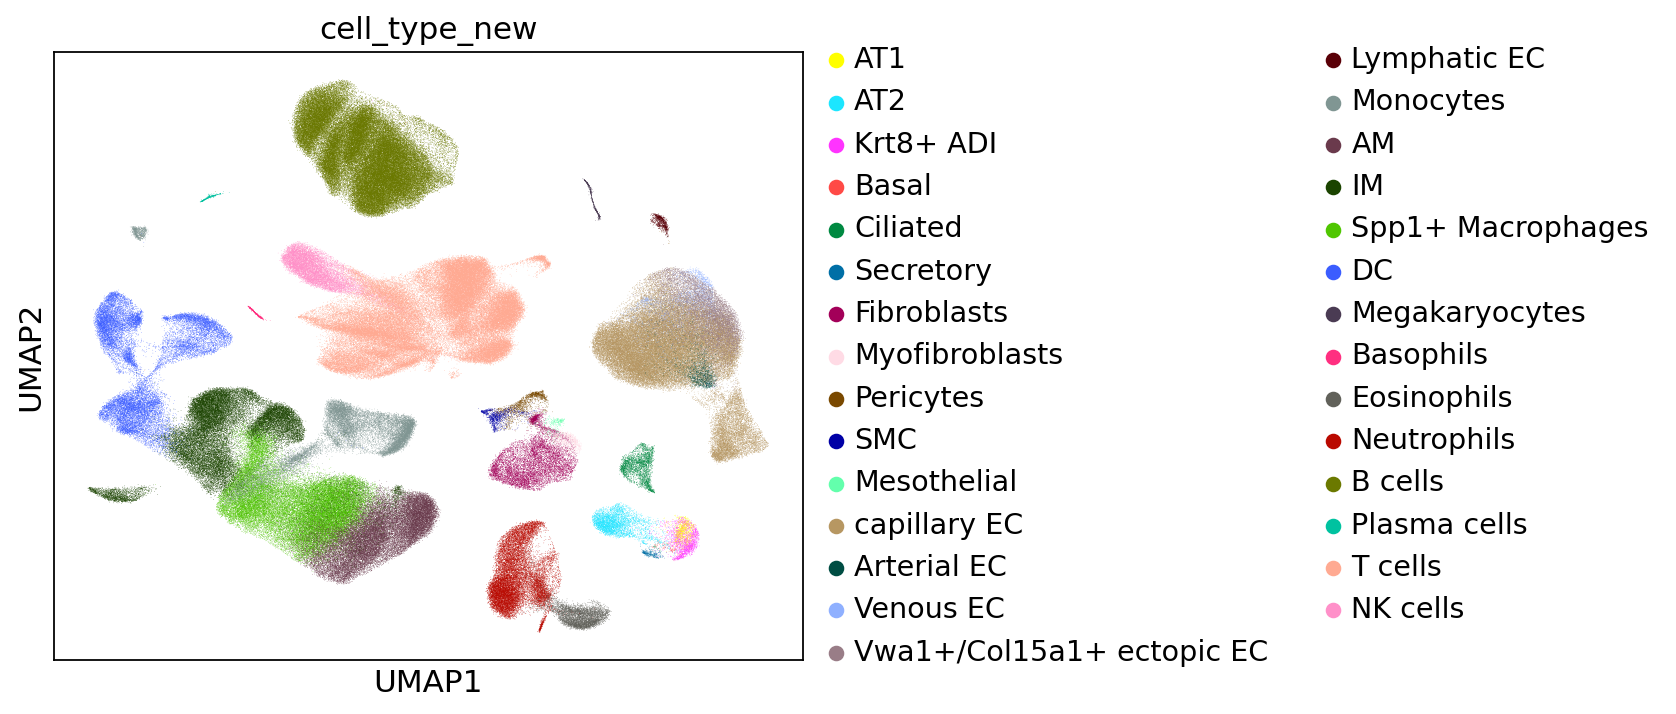

In [11]:
## reorder treatment labels
adata.obs['cell_type_new'] = adata.obs['cell_type_new'].astype('category')
adata.obs['cell_type_new'] = adata.obs['cell_type_new'].cat.reorder_categories(['AT1',
                                                                        'AT2',
                                                                        'Krt8+ ADI',
                                                                        'Basal',
                                                                        'Ciliated',
                                                                        'Secretory',
                                                                        
                                                                        'Fibroblasts',
                                                                        'Myofibroblasts',
                                                                        'Pericytes',
                                                                        'SMC',
                                                                        'Mesothelial',
                                                                        
                                                                        'capillary EC',
                                                                        'Arterial EC',
                                                                        'Venous EC',
                                                                        'Vwa1+/Col15a1+ ectopic EC',
                                                                        'Lymphatic EC',
                                                                        
                                                                        'Monocytes',
                                                                        'AM',
                                                                        'IM',
                                                                        'Spp1+ Macrophages',
                                                                        'DC',
                                                                        
                                                                        'Megakaryocytes',
                                                                        
                                                                        'Basophils',
                                                                        'Eosinophils',
                                                                        'Neutrophils',
                                                                        
                                                                        'B cells',
                                                                        'Plasma cells',
                                                                        'T cells',
                                                                        'NK cells'
                                                                        ])
sc.pl.umap(adata, color = 'cell_type_new')

### Assess cell type specificity

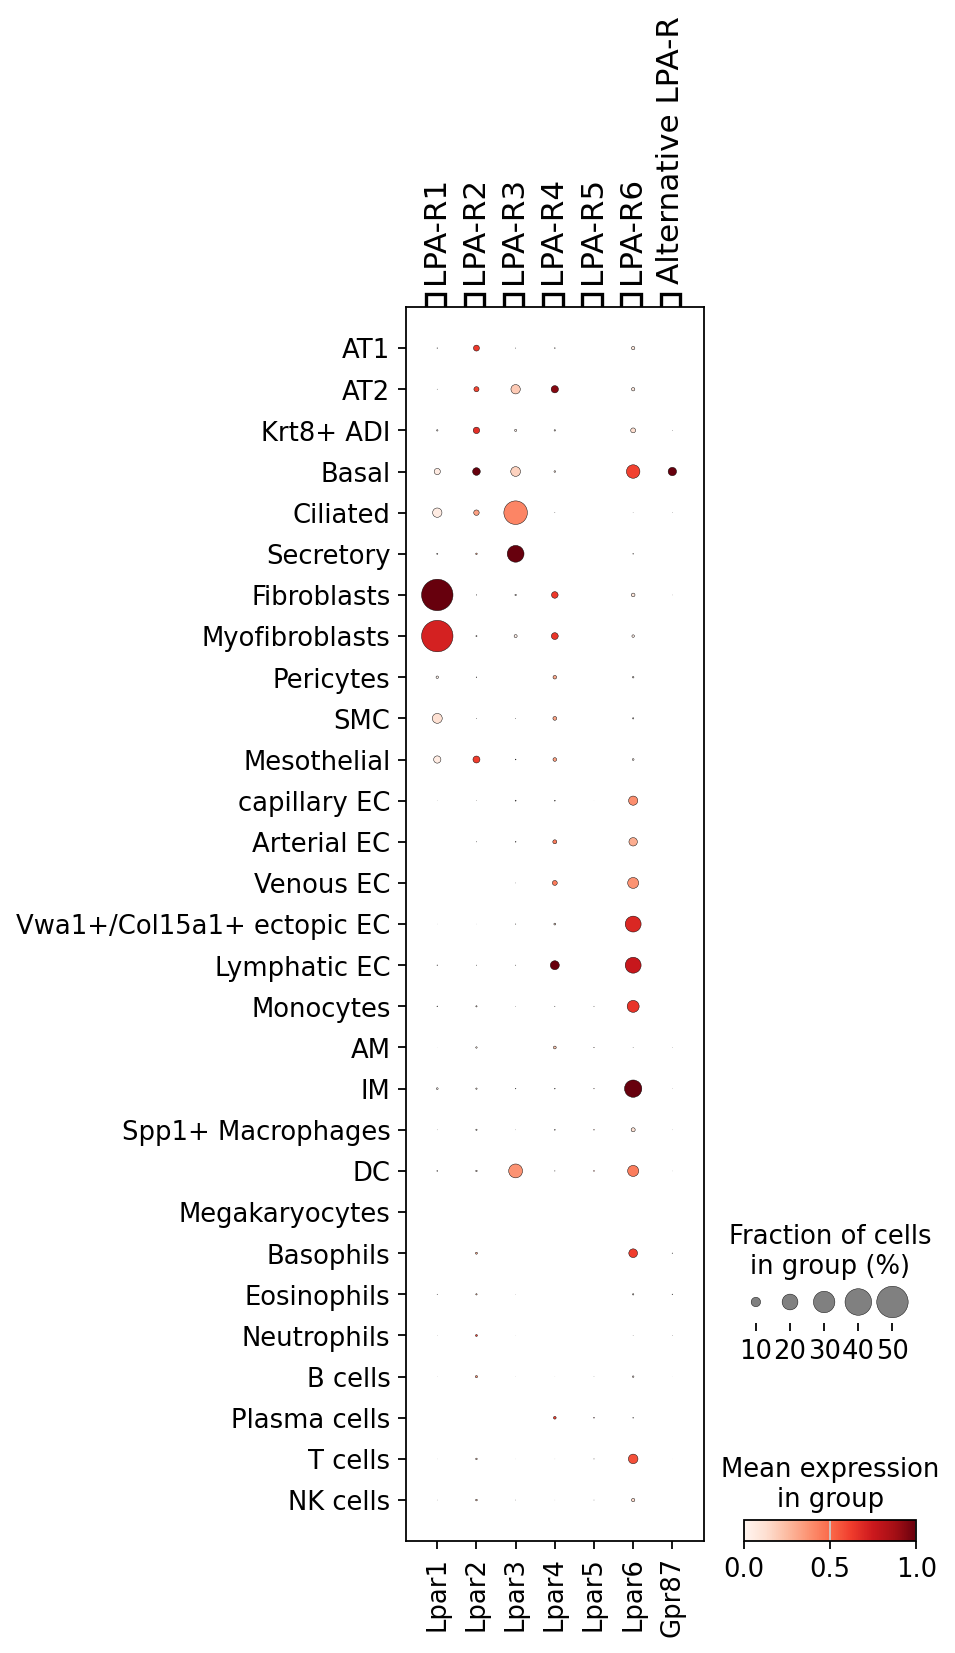

In [12]:
sc.pl.dotplot(adata,
              var_names = lpa_receptors, 
              groupby = 'cell_type_new',
              standard_scale = 'var',
              dot_max = 0.5,
              cmap = 'Reds',
              save = 'mouse_cell_type_specificity_lpa_receptors.pdf'
             )

In [13]:
adata.obs.treatment.cat.categories

Index(['none', 'vehicle', 'Nintedanib', 'GLPG1205', 'GLPG1690', 'Combo'], dtype='object')

In [14]:
eos = adata[adata.obs.cell_type.isin(['Eosinophils'])].copy()
monos = adata[adata.obs.cell_type.isin(['Transitional Monocytes'])].copy()

In [15]:
eos = eos[eos.obs.treatment.isin(['vehicle','GLPG1690'])].copy()
monos = monos[monos.obs.treatment.isin(['vehicle','GLPG1690'])].copy()

In [16]:
eos

AnnData object with n_obs × n_vars = 2333 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21', 'cell_type_new'
    var: 'n_counts', 'n_cells', 'highly_variable', 

In [17]:
monos

AnnData object with n_obs × n_vars = 2039 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21', 'cell_type_new'
    var: 'n_counts', 'n_cells', 'highly_variable', 

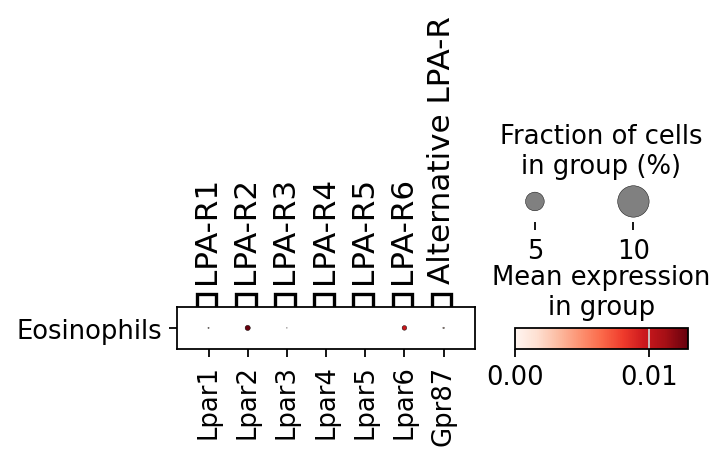

In [18]:
sc.pl.dotplot(eos,
              var_names = lpa_receptors, 
              groupby = 'cell_type_new',
              dot_max = 0.1,
              cmap = 'Reds',
              save = 'mouse_eosinophils_lpa_receptors.pdf'
             )

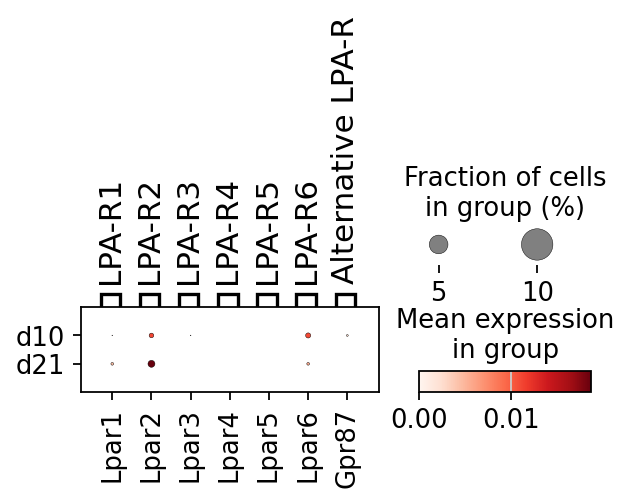

In [19]:
sc.pl.dotplot(eos,
              var_names = lpa_receptors, 
              groupby = 'time_point',
              dot_max = 0.1,
              cmap = 'Reds',
              save = 'mouse_eosinophils_lpa_receptors_time_point.pdf'
             )

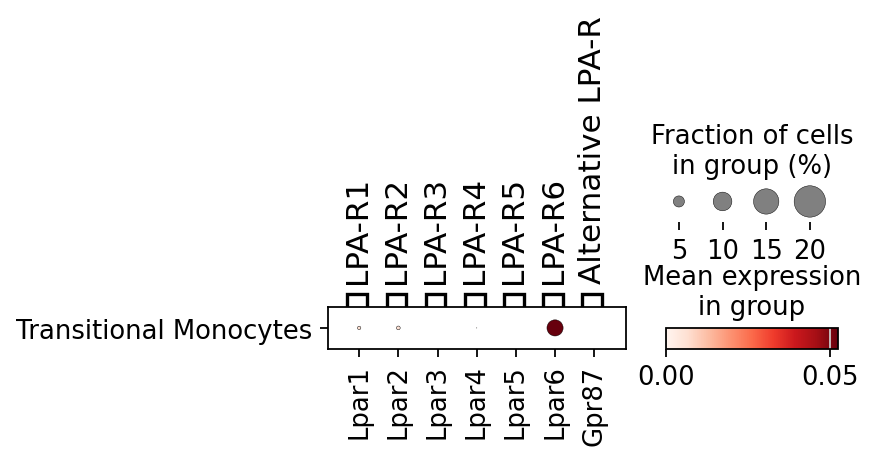

In [25]:
sc.pl.dotplot(monos,
              var_names = lpa_receptors, 
              groupby = 'cell_type',
              dot_max = 0.2,
              cmap = 'Reds',
              save = 'mouse_monocytes_lpa_receptors.pdf'
             )

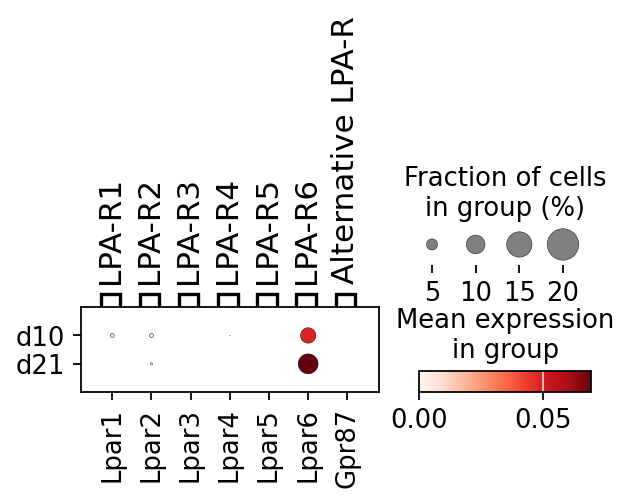

In [26]:
sc.pl.dotplot(monos,
              var_names = lpa_receptors, 
              groupby = 'time_point',
              dot_max = 0.2,
              cmap = 'Reds',
              save = 'mouse_monocytes_lpa_receptors_time_point.pdf'
             )